In [24]:
#----------------------------------------------------- Optimistic

import matplotlib.pyplot as plt
import numpy as np

def rangewf(start, stop, step):
    while stop > start:
        yield start
        start += step

# variable initialization
sz=100
s=(100,100)
x=np.zeros(sz,float)
y=np.zeros(sz,float)
z=np.zeros(s,float)

cy=2;                 # construction years
cd=[0.6, 0.4, 0, 0, 0];   # CAPEX split between the construction years 

pl=20;                # Plant life
SF = 0.9;             # Stream factor
tpa=2000000;          # desired C2H4 in MMT/yr or TPA
tr=0.39;              # tax rate
lc=10;                # Land cost $10 mil 
c2cconv=100;          # CO3 to CO2 conversion
h2ocost=0.1;          # $/m3
kohcost=0.0005;       # $/kg

## variable initialization (within SVSA loop)
capdis=cd; 

depp = [0.1, 0.18, 0.14, 0.12, 0.09, 0.07370, 0.06550, 0.06550, 0.06550, 0.06550, 0.03,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]; # 10-yr MACRS: Modified Accelerated Cost Recovery System
projLife = pl;
cons_yrs = cy;
desired_C2H4=tpa;

Taxrate = tr; 
landcost = lc;
CWT = 0 ;
WACC=0.1;
Salval=0;

totyrs = cons_yrs + projLife + 1;

  
num= [0,0.9,0.75,1.5,3.5,0.95,165,7,0.75,0.65,1,1.15,0.015,0.65,0.25,0.75,6,1500,0.8,20,7,1.5,10000,60, 7];

#titles=['Capture efficiency (#)', 'Capital cost (#)', "Threshold CO3 concentration (M)", "Membrane permeance (L/m**2/h/bar)[GO]", 
#       "CO3 Rejection (#)[GO]", 'Membrane cost ($/m**2)[GO]', "Membrane Lifetime (years)[GO]", 'Stack cost (#)', 'Single pass conversion (#)', 
#       'Current density (mA/cm**2)', 'Price of Product (#)', 'Electricity cost ($/kWh)', 'Faradaic efficiency C2H4 (#)', 
#       'Faradaic efficiency C2H5OH (#)',  'Cell Voltage (#)', 'Electrode area per cell (m**2)', 'H2 permeance (GPU)[HF]', 'C2H4 permeance (GPU)[HF]', 
#       'Membrane cost ($/m**2)[HF]', 'Membrane lifetime (years)[HF]', 'Water flux (LMH)[Pervap]', 'Membrane selectivity [Pervap]', 
#       'Membrane cost ($/m**2)[Pervap]', 'Membrane lifetime (years)[Pervap]'];
     
jh=0
cost=[]
for J in rangewf(0.2, 1.4, 0.012):
    i=0
    for num[12] in rangewf(0.0056, 0.065, 0.0006):
#--------------------------------------------------------------CCU calculations
        capturerate = 31.501*num[1] -0.1837;                        # t-CO2/m2/yr : correlation from CCU_calc sheet in data folder
        kohconc = 2.5;                                              # mol/L
        RR = 2.8;                                                   # recycle ratio
        co22bcap= (desired_C2H4* 1000/ 28/ 365/ 86400) /num[1] /num[5] /num[9] /(num[13]/(num[14]+num[13])) *2 /RR; # kmol/s : desired_C2H4 / capt_eff / rejection / SP_conv / Selecitivity_C2H4 (!= FE_C2H4) *2 carbonates per mol of C2+ prod
        
        if num[5]<0.75:
            co22bcap = co22bcap /0.45*RR;                           # 45# rej for stage 2

        kohCCU= co22bcap/0.13*56*RR;                                # kg/s
        waterCCU= kohCCU/56*1000/kohconc;                           # kg/s
        CCUarea= co22bcap*44/capturerate/1000*3600*24*365*SF;       # m**2
        
        FCILCCU= 5386.5*(CCUarea)*1.18*num[2]*1.5;
        CRMCCU = (((waterCCU)*h2ocost*0.001)+(kohCCU*kohcost))*365*24*3600*SF/1000000;
        CRRCCU = FCILCCU*0.05/7/1000000;
        CUTCCU = (SF*365*24)*125.44*1.6/(60/100)/1000*CCUarea*num[12]/1000000; # packing pr drop = 125.44 Pa/m, air velocity =1.6 m/s, fan efficiency = 60# 
        
#--------------------------------------------------------------Membrane concentrator calculations
    ## CO3 concentrating stages
        if num[5]>0.8:
            rej_co3= num[1]* co22bcap* num[5]* RR;               # kmol/s
            waterperm= waterCCU -  rej_co3*(1000)/num[3];        # kg/s (assuming density =1)
            TMP = 50;                                            # bar : transmembrane pressure
            memarea_t= waterperm/num[4]/TMP*3600;                # m**2 
        else:
            rej_co3_1= num[1]* co22bcap* num[5]*RR;              # kmol/s
            waterperm_1= waterCCU*0.5 -  rej_co3_1*(1000)/1.25;  # kg/s
            TMP = 50;                                            # bar : transmembrane pressure
            memarea_1= waterperm_1/num[4]/TMP*3600;              # m**2 

            rej_co3_2= num[1]* co22bcap* num[5] *0.45 *RR;       # kmol/s
            waterperm_2= waterCCU*0.5 -  rej_co3_2*(1000)/num[3];# kg/s
            TMP = 50;                                            # bar : transmembrane pressure
            rej_co3 = rej_co3_1 + rej_co3_2;
            memarea_t= waterperm_2/num[4]/TMP*3600 + memarea_1;  # m**2
            waterperm = (waterperm_1 + waterperm_2)*0.25;
        
    ## Recovery stage
        rejco3_r= (co22bcap*RR - rej_co3)* num[5];               # kmol/s
        waterperm_r= waterperm -  rejco3_r*(1000)/0.5;           # kg/s
        TMP = 50;                                                # bar : transmembrane pressure
        memarea_r= waterperm_r/num[4]/TMP*3600;                  # m**2 

        FCILGO=num[6]*((memarea_t + memarea_r)**0.85)*1.18*(pl/num[7])*1.5*1.18; 
        CUTGO=(waterCCU)*1000* 9.81* 1*num[12]*24*365/3.6e6/1000000; # All in SI: Q* rho* g* head* eleccost/ 3.6E6
        CRRGO = FCILGO*0.05/7/1000000;
    
#--------------------------------------------------------------electrolyzer calc
    ## electrolyzer calc
        n_C2H4=12;
        FECO  =0;
        FECH4 =0;
        FEH2  =1- num[13] -num[14] -FECO -FECH4;
        V = (4.1* J+ 2.3943)* num[15];         # Full cell voltage in volts from shin et al. (BPM)
        # V = (0.2508* ln(J)+ 1.106)* num[15]  # Full cell voltage in volts from shin et al. (AEM)
        max_co2 = co22bcap *num[1] *num[5] *RR;      # kmol/s : max CO2 to the EchemR to convert to product
        Itot = max_co2* n_C2H4 *96485 *1000 *num[9] /((num[14]+num[13])) /2 ; # A
        Elecarea = Itot/J/10000;               # m**2
        power = Itot * V/1000;                       # in kW 
        
    ## stack design parameters
        cellperst = 150;
        areapercel = num[16];                        # m**2
        areaperst = areapercel* cellperst;           # m**2
        stacktot = round(Elecarea/areaperst);      

    ## stack costing: refer stack costing excel sheet
        #         part_coeff = [21.142, 62.9245502, 9.2850859, 88.2076914, 192.6642591, 39.4613508, 74.2802067];          # BPM w/ catholyte 1000
        part_coeff = [0, 194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003];     # BPM w/ catholyte 100

        #         part_coeff = [21.142, 55.493906, 11.487794, 87.1627, 204.1164, 39.0166, 77.9371];               # AEM w/ catholyte 1000
        cath_flow = part_coeff[1]*(areaperst/0.0961) **0.85/1000000*stacktot;
        cath_gdl  = part_coeff[2]*(areaperst/0.0676) **0.85/1000000*stacktot;
        bpm       = part_coeff[3]*(areaperst/0.0961) **0.85/1000000*stacktot;
        anod_gdl  = part_coeff[4]*(areaperst/0.0676) **0.85/1000000*stacktot;
        mea_fr    = part_coeff[5]*(areaperst/0.0961) **0.85/1000000*stacktot;
        bpp       = part_coeff[6]*(areaperst/0.0961) **0.85/1000000*stacktot;
        stack_ass = part_coeff[7]*(areaperst/0.0961) **0.85/1000000*stacktot;
        FCILEchemR  = (cath_flow + cath_gdl + bpm + anod_gdl + mea_fr + bpp + stack_ass)*1000000*num[8]*1.5*1.18;
        CUTEchemR = power*num[12]*24*365*SF/1000000;
        
    ## Product distribution 
        h2   = Itot*FEH2*3600/1000*2.015/96485/2;        # kg/hr
        CO   = Itot*FECO*3600/1000*28.01/96485/2;        # kg/hr
        ethy = desired_C2H4*1000/365/24;                 # kg/hr
        etha = Itot*num[14]*3600/1000*46/96485/12;       # kg/hr 
        O2   = Itot*3600/1000/4/96485*32;                # kg/hr 
        H2Oin  = (ethy/28.05*4+etha/46.06*3+CO/28.01)*18 + (rej_co3*(1000)/num[3]*3600);               # kg/hr 
        H2Oreq = ((ethy/28*12)+(h2/2*2)+(etha/46*12)+(CO/28*2)+(ethy/28*2 + etha/46*2 + CO/28*1))*18;  # kg/hr 
      
        CRMEchemR = (H2Oreq)*h2ocost/1000*365*24*SF/1000000;
        CRREchemR = FCILEchemR* 0.05/7 /1000000;
        prodincome=(0.6*CO + 1.06*ethy + 1.2*h2 + 0.1*O2 + 1*etha)*num[11]*24*365*SF/1000000;
    
#--------------------------------------------------------------Downstream separations
    ## cathode gas separation
        x_H2 = h2/2/(h2/2+ethy/28);                                      # feed H2 mol fraction
        Pf = 2;                                                          # bar : feed pressure
        ZHFarea=(h2/2/3600)/(num[17]*3.35e-10)/(Pf* 100000* x_H2)*1000;  # values subject to changes
        FCILZHF=num[19]*((ZHFarea)**0.85)*1.18*(pl/num[20])*1.5*1.18; 
        CUTZHF =(h2/3600)*1* 9.81* 1*num[12]*24*365/3.6e6/1000000; 
        CRRZHF = FCILZHF* 0.05/7 /1000000;
        
    ## cathode liq separation
        # (1) distillation
        flow_in = (H2Oin-H2Oreq + etha)/60;                 # L/min, density =1 
        FCILdis = 4162240*(flow_in/1000)**0.7;               # cost calc from Jouny et al.    
        reboiler = flow_in* 4.18* (78-25) + 3*etha*896000;  # J/hr Reboiler duty: https://www.chemengghelp.com/mb-hb-distillation-process/#Utility_Requirement_for_Distillation_Column (CP water = 4.18 J/kg/C) (Latent ht of vap top prod (Ethanol) = 896 kJ/kg) (temp bottoms =78, temp feed =25: https://www.researchgate.net/figure/Composition-profile-in-each-stage-for-the-ethanol-water-system-in-the-optimal_fig4_334523794)(1:2 reflux ratio)
        condensor= etha*0.00246* (98-5)+   3*etha*896000;   # J/hr 5C subcooled distillate (CP ethanol = 0.00246 J/kg/C) (Latent ht of vap etha = 896 kJ/kg) 
        CUTdis=(((reboiler + condensor)/1000)*24*365*num[12]/10000 + reboiler/1744*h2ocost/1000 + condensor/(6)*h2ocost/1000)/1000000; # coolant flow+ heating requirement (1744 = latent heat of steam, chek the link above for more info)

    ## (2) pervaporation
        q_h2o = etha*0.05;                                             # water in feed
        Pf = 1;                                                        # bar : feed pressure
        pervaparea= (q_h2o*0.999)/(num[21]/18);                        # desired ethanol purity in permeate
        FCILpervap= num[23]*((pervaparea)**0.85)*1.18*(pl/num[24])*1.5*1.18; 
        CUTpervap = (q_h2o/3600)*1000* 9.81* 1*num[12]*24*365/3.6e6/1000000; 
        CRRpervap = FCILpervap* 0.05/7 /1000000;
        
    
#--------------------------------------------------------------total CAPEX & OPEX
        CUTI = CUTCCU + CUTGO + CUTEchemR + CUTZHF + CUTdis + CUTpervap;      # million USD
        FCILbop = 0.35*(FCILEchemR/0.65);                                     # USD 
        FCIL = FCILCCU + FCILGO + FCILEchemR + FCILZHF + FCILdis + FCILbop + FCILpervap;   # USD     
        CRR = CRRCCU + CRRGO + CRREchemR + CRRZHF + CRRpervap;                # million USD: Running and replacement
        CRM = CRMCCU + CRMEchemR;                                             # million USD: Raw materials
        NOL = (6.29 + 31.7* (0)**2 + 0.23*(8+stacktot))**0.5;                   # Eqn 8.3 richard turton, 8 unit ops
        COL = 4.5* NOL* (32.77*2000)/1000000;                                 # million USD: 245 shifts per operator, 1095 operating shifts per plant: 4.5 operators per required operator for the plant; per operator cost is 32.77 usd/hr, 2000 hrs per yr: https://www.bls.gov/regions/southwest/news-release/employercostsforemployeecompensation_regions.htm 
        workex = 0.1*CRM + 0.1*FCIL/1000000 + 0.1*COL;                        # working capital (millions USD)
        COMd = 0.18 * (FCIL/1000000) + 2.76 * COL + 1.23* (CUTI + CWT + CRM + CRR); # million USD
    
#--------------------------------------------------------------Ethylene base case cost estimation
    ## Ethylene base case production cost (bcpc) estimation
        j=1;
        for bcpc in rangewf(0,200,0.05):                                     
            prodincome=(0.6*CO + bcpc*ethy + 1*h2 + 0.1*O2 + 1*etha)*24*365*SF*num[11] /1000000;

    ## Profitability analysis
        # defining arrays
            Arr=np.zeros((100,5),float);

            # year 0 done separately as b4
            Start = 1;

            Arr[Start, 1] = -landcost;              # Non-discounted After tax cash flow
            Arr[Start, 2] = Arr[Start, 1];          # Cummulative Non-discounted After tax cash flow
            Arr[Start, 3] = Arr[Start, 1];          # Cummulative Discounted After tax cash flow

            Start = 2;

            while Start <= cons_yrs+1:
                Arr[Start, 1] = -(FCIL / 1000000) * capdis[Start - 1];
                if Start == cons_yrs+1: 
                    Arr[Start, 1] = -(workex) - ((FCIL / 1000000) * capdis[Start - 1]);

                Arr[Start, 2] = Arr[Start, 1] + Arr[Start - 1, 2];
                Arr[Start, 3] = Arr[Start, 1] / ((1 + WACC) ** (Start-1)) + Arr[Start - 1, 3];
                Start = Start + 1;

            t=Start;        
            while t <= totyrs:
                if (Start-cons_yrs)>10:
                    depp[Start]=0;

                Arr[Start, 1] = (prodincome - COMd - (FCIL / 1000000) * depp[Start - cons_yrs]) * (1 - Taxrate) + (FCIL / 1000000) * depp[Start - cons_yrs];
                Arr[Start, 2] = Arr[Start, 1] + Arr[Start - 1, 2];
                Arr[Start, 3] = Arr[Start, 1] / ((WACC + 1) ** (Start-1)) + Arr[Start - 1, 3];
                Arr[Start, 4] = (prodincome - COMd - (FCIL / 1000000) * depp[Start - cons_yrs]) * (1 - Taxrate);

                if Start == totyrs: 
                    Arr[Start, 1] = (prodincome + Salval / 1000000 - COMd - (FCIL / 1000000) * depp[Start - cons_yrs]) * (1 - Taxrate) + (FCIL / 1000000) * depp[Start - cons_yrs] + workex + landcost;
                    Arr[Start, 2] = Arr[Start, 1] + Arr[Start - 1, 2];
                    Arr[Start, 3] = Arr[Start, 1] / ((WACC + 1) ** (Start-1)) + Arr[Start - 1, 3];
                    Arr[Start, 4] = (prodincome - COMd - (FCIL / 1000000) * depp[Start - cons_yrs]) * (1 - Taxrate);
                t = t + 1;
                Start = Start + 1;

        ## NPV value calculation
            Start = totyrs;
            NPV = Arr[Start, 3];

            if j!=1 and NPV>0:  
                break
            j=j+1;
        z[i,jh]=bcpc
        i=i+1
    jh=jh+1

C:\Users\venka\AppData\Local\Temp\ipykernel_21140\120992403.py:17: UserWarning: The following kwargs were not used by contour: 'linewidth'
  CS = ax.contour(xs, ys, z.T, linewidth = 2, linestyles = 'dotted', colors = 'black' )


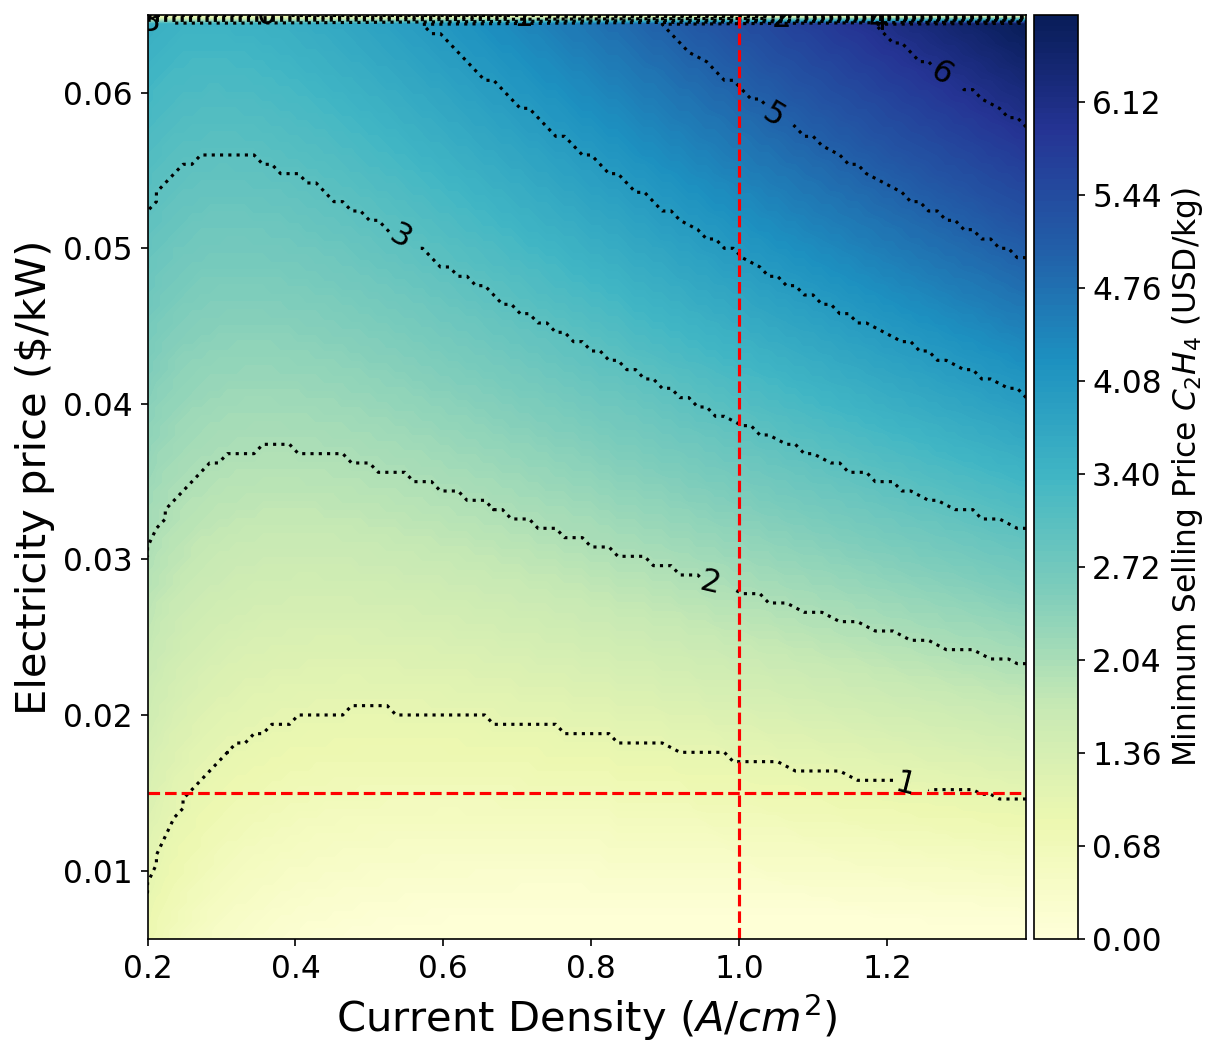

In [25]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} " if plt.rcParams["text.usetex"] else f"{s} "

plt.rcParams.update({'font.size': 15})

x=np.arange(0.2, 1.4, 0.012)
y=np.arange(0.0056, 0.065, 0.0006)

fig, ax = plt.subplots(figsize = (8,8), dpi =150)
ys, xs = np.meshgrid(y, x)
im = ax.contourf(xs, ys, z.T, 200, cmap = 'YlGnBu') ### the value reduces the color edges, higher it is, more will be the blend
CS = ax.contour(xs, ys, z.T, linewidth = 2, linestyles = 'dotted', colors = 'black' )
ax.clabel(CS, CS.levels, inline=True, fmt=fmt, fontsize=15)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

fig.colorbar(im, label="Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", cax =cax)
ax.set_ylabel('Electricity price ($/kW)', fontsize = 20)
ax.set_xlabel('Current Density ($A/cm^2$)', fontsize = 20)
ax.axhline(y=0.015,color='r',ls="--", label='2-stack rate')
ax.axvline(x=1,color='r',ls="--", label='2-stack rate')

plt.show()

# OLD Calculation, DO NOT USE

In [ ]:
bcpc
